In [17]:
# Importando as bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
print(os.listdir('.'))

['data', 'detran.ipynb', 'main.ipynb', 'tab111_IPVA_Regiao_Municipios_(2009-2024).xlsx']


In [40]:
def load_clean_sefaz_excel(year):
    filename = f'tab111_IPVA_Regiao_Municipios_(2009-2024).xlsx'
    
    if not os.path.exists(filename):
        print(f"Erro: Ficheiro {filename} não encontrado.")
        return None

    # Lendo o Excel: 
    # Se cada ano for uma ABA, usamos sheet_name=str(year)
    # skiprows=10 ignora o cabeçalho administrativo da SEFAZ
    try:
        df = pd.read_excel(filename, sheet_name=str(year), skiprows=10, engine='openpyxl')
    except:
        # Caso o ano esteja num ficheiro separado e não em abas
        filename_sep = f'tab111_IPVA_Regiao_Municipios_(2009-2024).xlsx - {year}.xlsx'
        if os.path.exists(filename_sep):
            df = pd.read_excel(filename_sep, skiprows=10, engine='openpyxl')
        else:
            return None

    # Tratamento de Células Mescladas (Região)
    # O Excel da SEFAZ só escreve a região na primeira linha do bloco
    col_regiao = 'IPVA - Região' if 'IPVA - Região' in df.columns else 'IPVA - Regiao'
    df[col_regiao] = df[col_regiao].ffill()

    # Limpeza de Ruído
    df = df[df['Município'].notna()]
    df = df[~df['Município'].str.contains('Total:', na=False, case=False)]

    # Reestruturação (Melt)
    # Transforma colunas de meses em uma única coluna de 'Data'
    id_vars = [col_regiao, 'Município']
    meses_cols = [c for c in df.columns if c not in id_vars]
    df_melted = df.melt(id_vars=id_vars, value_vars=meses_cols, var_name='Data', value_name='Valor')

    # Tipagem
    df_melted['Valor'] = pd.to_numeric(df_melted['Valor'], errors='coerce')
    df_melted['Ano'] = year
    
    return df_melted

In [39]:
# Gerando a base consolidada (2022 a 2024)
anos = [2022, 2023, 2024]
dfs_list = [load_clean_sefaz_excel(a) for a in anos]
df_ipva_full = pd.concat([d for d in dfs_list if d is not None], ignore_index=True)

print(f"Sucesso! Base consolidada com {len(df_ipva_full)} registos.")

Sucesso! Base consolidada com 23220 registos.


In [32]:
# Tratamento de Dados Final
# Garante que a coluna de Valor é numérica e a Data é um objeto datetime
df_ipva_full['Valor'] = pd.to_numeric(df_ipva_full['Valor'], errors='coerce')
df_ipva_full['Data'] = pd.to_datetime(df_ipva_full['Data'])

In [33]:
# Análise de Sazonalidade Mensal (Média 2022-2024)
# Agrupamos por mês para identificar o padrão de pagamento do contribuinte
sazonalidade = df_ipva_full.groupby(df_ipva_full['Data'].dt.month)['Valor'].sum() / 3

# Análise de Concentração Regional (Dados de 2024)
# Filtramos apenas o ano de 2024 para ver a foto mais recente da arrecadação
df_2024 = df_ipva_full[df_ipva_full['Data'].dt.year == 2024]
col_regiao = 'IPVA - Região' if 'IPVA - Região' in df_2024.columns else 'IPVA - Regiao'
regioes_2024 = df_2024.groupby(col_regiao)['Valor'].sum().sort_values(ascending=False)

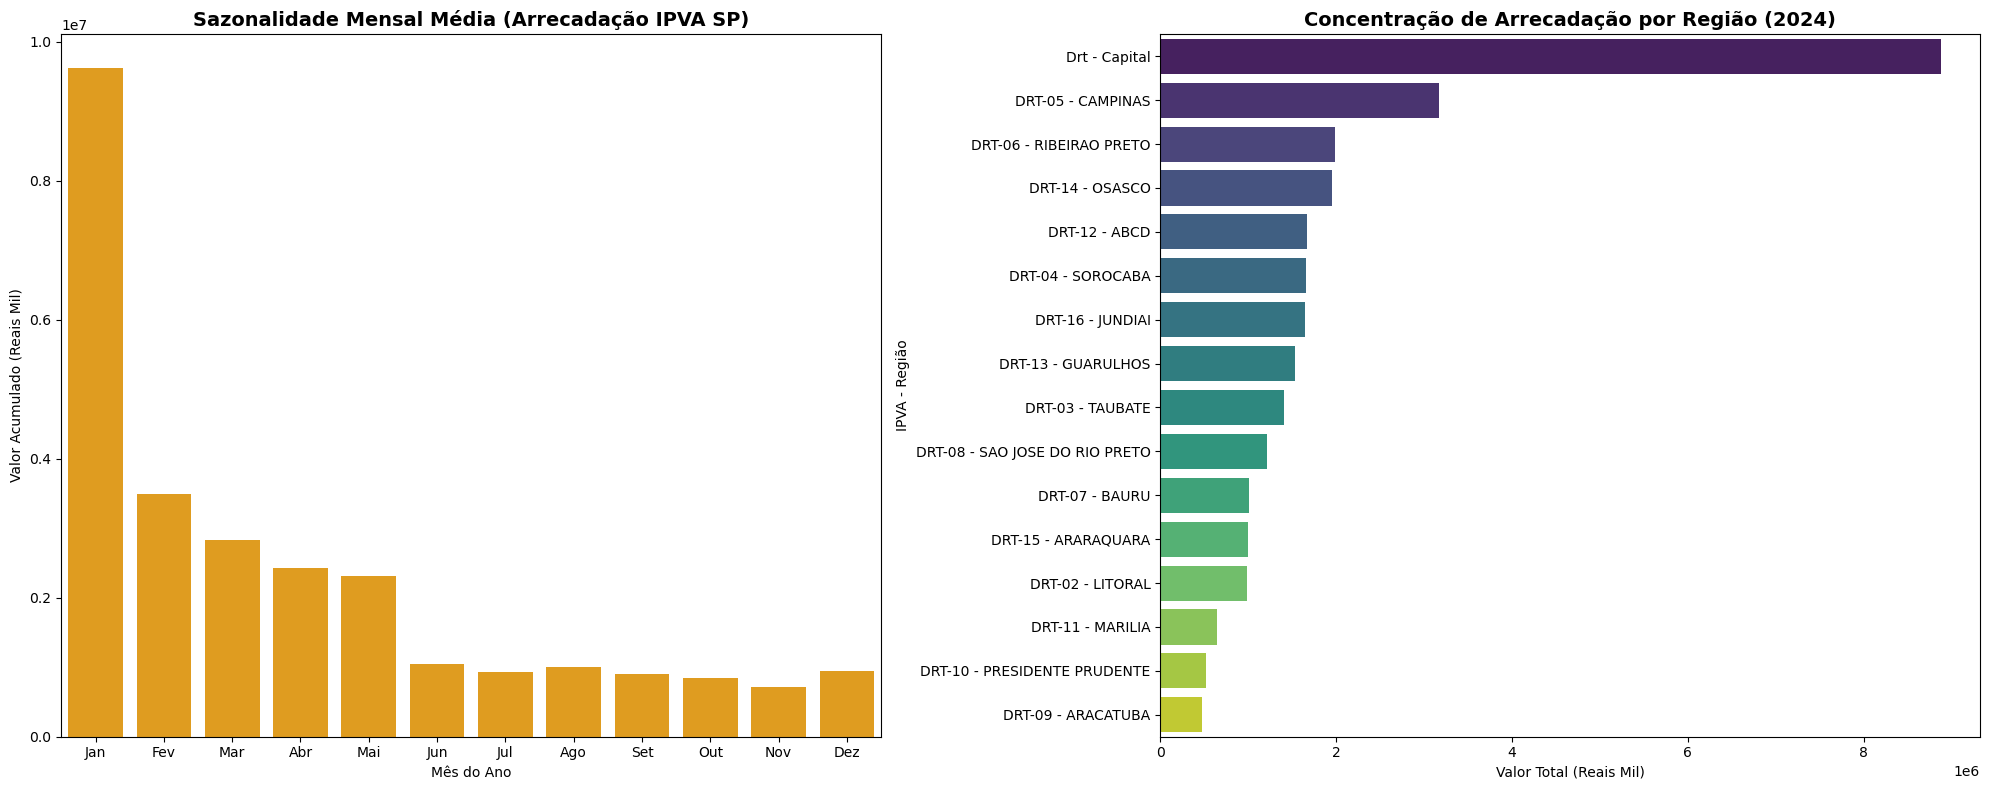

In [37]:
# --- CRIAÇÃO DOS GRÁFICOS ---
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

# Gráfico 1: Sazonalidade 
sns.barplot(x=sazonalidade.index, y=sazonalidade.values, ax=ax[0], color='orange')
ax[0].set_title('Sazonalidade Mensal Média (Arrecadação IPVA SP)', fontsize=14, fontweight='bold')
# Primeiro definimos os ticks, depois os nomes (evita o UserWarning)
ax[0].set_xticks(range(0, 12)) 
ax[0].set_xticklabels(['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])
ax[0].set_ylabel('Valor Acumulado (Reais Mil)')
ax[0].set_xlabel('Mês do Ano')

# Gráfico 2: Concentração Regional
sns.barplot(x=regioes_2024.values, y=regioes_2024.index, ax=ax[1], hue=regioes_2024.index, palette='viridis', legend=False)
ax[1].set_title('Concentração de Arrecadação por Região (2024)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Valor Total (Reais Mil)')

plt.tight_layout()
plt.show()

In [38]:
pico_jan = sazonalidade[1]
vale_jun = sazonalidade[6]
print(f"--- INSIGHTS PARA O RELATÓRIO ---")
print(f"Volume Médio em Janeiro: R$ {pico_jan:,.2f}")
print(f"O volume de Janeiro é {pico_jan/vale_jun:.1f}x maior que o de Junho.")
print(f"Top 3 Regiões para Focar: {', '.join(regioes_2024.index[:3].tolist())}")

--- INSIGHTS PARA O RELATÓRIO ---
Volume Médio em Janeiro: R$ 9,623,102.52
O volume de Janeiro é 9.2x maior que o de Junho.
Top 3 Regiões para Focar: Drt - Capital, DRT-05 - CAMPINAS, DRT-06 - RIBEIRAO PRETO
